In [1]:
import numpy as np
import matplotlib.pyplot as plt

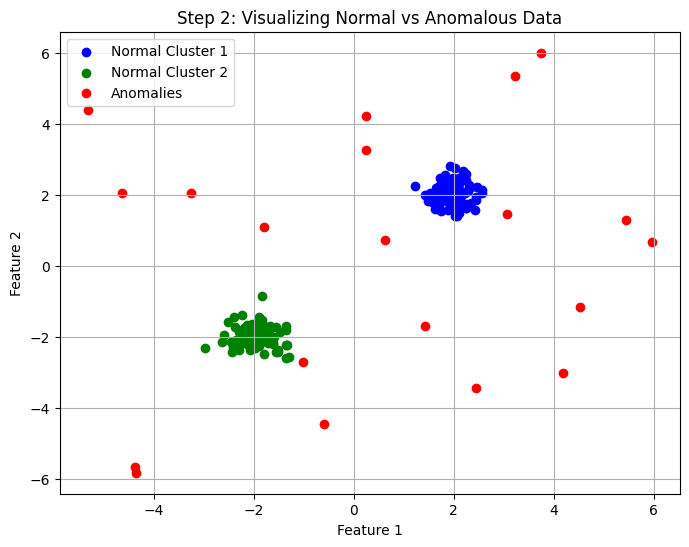

In [2]:
rng = np.random.RandomState(42)
normal_data1 = 0.3 * rng.randn(100, 2) + [2, 2] 
normal_data2 = 0.3 * rng.randn(100, 2) + [-2, -2]  


anomalies = rng.uniform(low=-6, high=6, size=(20, 2))


X = np.vstack([normal_data1, normal_data2, anomalies])

# Plotting
plt.figure(figsize=(8, 6))
plt.scatter(normal_data1[:, 0], normal_data1[:, 1], c='blue', label='Normal Cluster 1')
plt.scatter(normal_data2[:, 0], normal_data2[:, 1], c='green', label='Normal Cluster 2')
plt.scatter(anomalies[:, 0], anomalies[:, 1], c='red', label='Anomalies')
plt.title("Step 2: Visualizing Normal vs Anomalous Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


In [20]:
import pandas as pd
import logging

logging.basicConfig(
    filename="info_log.log",
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
try:
    df=pd.read_csv('creditcard.csv')
    logging.info("Data Set Muvaffaqiyatli Yuklandi")
except FileNotFoundError as e:
    logging.error("Data Set Topilmadi: %s", e)



In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Featurelari
1) Time--Transactionlar orasidagi muddat
2) V1-V28=Anonimlashtirilgan featurelar
3) Amount=Transaction miqdor
# Class kerak emas for prediction

In [6]:
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:

x = df.drop('Class', axis=1)
y = df['Class']

scaler = StandardScaler()
x[['Time', 'Amount']] = scaler.fit_transform(x[['Time', 'Amount']])

In [9]:
iso_forest = IsolationForest(
    n_estimators=100,
    max_samples='auto',
    contamination=0.1,  
    random_state=42
)


iso_forest.fit(x)

IsolationForest(contamination=0.1, random_state=42)

In [10]:
y_pred = iso_forest.predict(x)

y_pred = [1 if x == -1 else 0 for x in y_pred]

In [11]:
y_pred

[0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 1,
 1,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,


In [12]:
print("Confusion Matrix:")
print(confusion_matrix(y, y_pred))

print("\nClassification Report:")
print(classification_report(y, y_pred, digits=4))

Confusion Matrix:
[[256268  28047]
 [    58    434]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9998    0.9014    0.9480    284315
           1     0.0152    0.8821    0.0300       492

    accuracy                         0.9013    284807
   macro avg     0.5075    0.8917    0.4890    284807
weighted avg     0.9981    0.9013    0.9464    284807



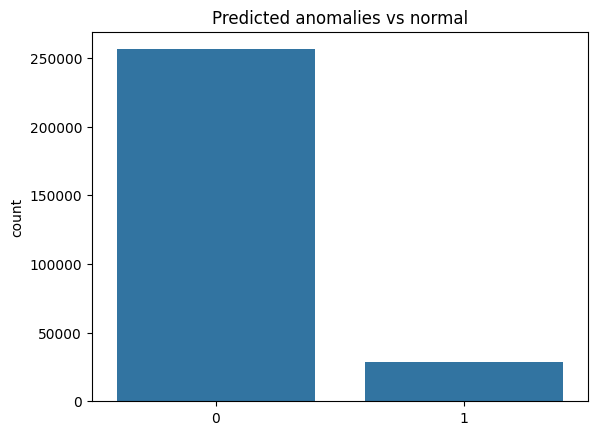

In [13]:
sns.countplot(x=y_pred)
plt.title("Predicted anomalies vs normal")
plt.show()

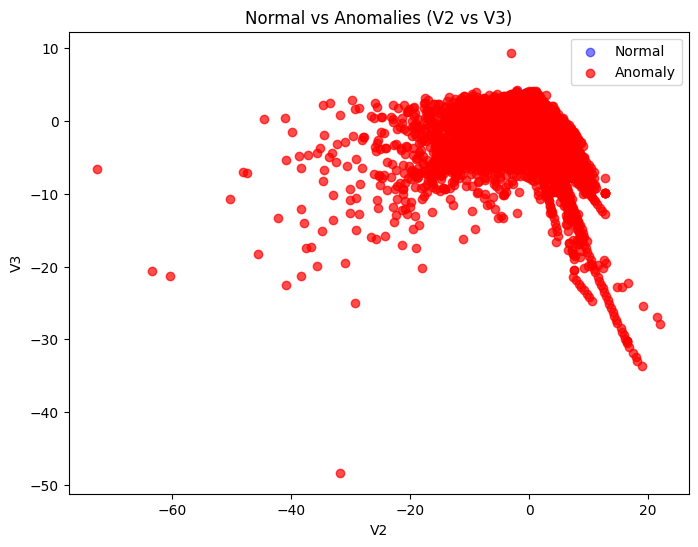

In [14]:
import matplotlib.pyplot as plt

y_pred_series = pd.Series(y_pred, index=x.index)

plt.figure(figsize=(8, 6))

plt.scatter(x[y_pred_series == 0]['V2'],
            x[y_pred_series == 0]['V3'],
            c='blue', label='Normal', alpha=0.5)


plt.scatter(x[y_pred_series == 1]['V2'],
            x[y_pred_series == 1]['V3'],
            c='red', label='Anomaly', alpha=0.7)

plt.title("Normal vs Anomalies (V2 vs V3)")
plt.xlabel("V2")
plt.ylabel("V3")
plt.legend()
plt.show()

In [15]:
df['anomaly'] = y_pred_series


anomalies = df[df['anomaly'] == 1]


print("Number of detected anomalies:", anomalies.shape[0])
print(anomalies.head())

Number of detected anomalies: 28481
    Time        V1        V2        V3        V4        V5        V6  \
2    1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499   
7    7.0 -0.644269  1.417964  1.074380 -0.492199  0.948934  0.428118   
14  12.0 -2.791855 -0.327771  1.641750  1.767473 -0.136588  0.807596   
18  14.0 -5.401258 -5.450148  1.186305  1.736239  3.049106 -1.763406   
51  36.0 -1.004929 -0.985978 -0.038039  3.710061 -6.631951  5.122103   

          V7        V8        V9  ...       V22       V23       V24       V25  \
2   0.791461  0.247676 -1.514654  ...  0.771679  0.909412 -0.689281 -0.327642   
7   1.120631 -3.807864  0.615375  ... -1.015455  0.057504 -0.649709 -0.415267   
14 -0.422911 -1.907107  0.755713  ...  0.222182  1.020586  0.028317 -0.232746   
18 -1.559738  0.160842  1.233090  ...  0.984460  2.458589  0.042119 -0.481631   
51  4.371691 -2.006868 -0.278736  ... -0.381671  0.969719  0.019445  0.570923   

         V26       V27       V28   Amount  C

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 32 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   Time     284807 non-null  float64
 1   V1       284807 non-null  float64
 2   V2       284807 non-null  float64
 3   V3       284807 non-null  float64
 4   V4       284807 non-null  float64
 5   V5       284807 non-null  float64
 6   V6       284807 non-null  float64
 7   V7       284807 non-null  float64
 8   V8       284807 non-null  float64
 9   V9       284807 non-null  float64
 10  V10      284807 non-null  float64
 11  V11      284807 non-null  float64
 12  V12      284807 non-null  float64
 13  V13      284807 non-null  float64
 14  V14      284807 non-null  float64
 15  V15      284807 non-null  float64
 16  V16      284807 non-null  float64
 17  V17      284807 non-null  float64
 18  V18      284807 non-null  float64
 19  V19      284807 non-null  float64
 20  V20      284807 non-null  

In [17]:
anomalies.to_csv('Anomalies.csv', index=False)
print("Anomal xolatlart  Anomalies.csv fayliga saqlandi")

Anomal xolatlart  Anomalies.csv fayliga saqlandi


In [18]:


df['Anomaly_Label'] = df['anomaly'].map({0: 'Normal', 1: 'Anomaly'})

print(df[['Class', 'anomaly', 'Anomaly_Label']].head(200))

     Class  anomaly Anomaly_Label
0        0        0        Normal
1        0        0        Normal
2        0        1       Anomaly
3        0        0        Normal
4        0        0        Normal
..     ...      ...           ...
195      0        0        Normal
196      0        0        Normal
197      0        0        Normal
198      0        0        Normal
199      0        0        Normal

[200 rows x 3 columns]
